In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, hamming_loss, classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('Dataset .csv', encoding='utf-8')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [11]:
df.info()
print(df['Cuisines'].isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [12]:
df = df.dropna(subset=['Cuisines']).reset_index(drop=True)
df['Cuisines'] = df['Cuisines'].apply(lambda x: x.split(', ') if pd.notnull(x) else [])
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['Cuisines'])
print("Number of classes:", len(mlb.classes_))
print("Sample classes:", mlb.classes_[:10])

Number of classes: 145
Sample classes: ['Afghani' 'African' 'American' 'Andhra' 'Arabian' 'Argentine' 'Armenian'
 'Asian' 'Asian Fusion' 'Assamese']


In [13]:
features = ['Country Code', 'City', 'Average Cost for two', 'Currency',
            'Has Table booking', 'Has Online delivery', 'Is delivering now',
            'Price range', 'Votes', 'Aggregate rating']
X = df[features].copy()
X['Has Table booking'] = X['Has Table booking'].map({'Yes':1, 'No':0})
X['Has Online delivery'] = X['Has Online delivery'].map({'Yes':1, 'No':0})
X['Is delivering now'] = X['Is delivering now'].map({'Yes':1, 'No':0})
X['Aggregate rating'] = X['Aggregate rating'].fillna(X['Aggregate rating'].median())
X = X.dropna().reset_index(drop=True)
y = y[X.index]

numeric_features = ['Average Cost for two', 'Price range', 'Votes', 'Aggregate rating']
categorical_features = ['Country Code', 'City', 'Currency']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

X_processed = preprocessor.fit_transform(X)
print("Processed feature shape:", X_processed.shape)

Processed feature shape: (9542, 171)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (7633, 171), Test: (1909, 171)


Logistic Regression

In [15]:
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [16]:
print("Logistic Regression Performance:")
print("Subset Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Hamming Loss:", hamming_loss(y_test, y_pred_lr))
print("Micro Precision:", precision_score(y_test, y_pred_lr, average='micro'))
print("Micro Recall:", recall_score(y_test, y_pred_lr, average='micro'))
print("Micro F1:", f1_score(y_test, y_pred_lr, average='micro'))
print("\nClassification Report (first 10 labels):")
print(classification_report(y_test, y_pred_lr, target_names=mlb.classes_, zero_division=0))

Logistic Regression Performance:
Subset Accuracy: 0.014667365112624411
Hamming Loss: 0.014295262007550442
Micro Precision: 0.5555555555555556
Micro Recall: 0.0685443668993021
Micro F1: 0.12203239405369426

Classification Report (first 10 labels):
                   precision    recall  f1-score   support

          Afghani       0.00      0.00      0.00         4
          African       0.00      0.00      0.00         3
         American       0.29      0.03      0.05        73
           Andhra       0.00      0.00      0.00         2
          Arabian       0.00      0.00      0.00         2
        Argentine       0.00      0.00      0.00         1
         Armenian       0.00      0.00      0.00         0
            Asian       1.00      0.02      0.04        50
     Asian Fusion       0.00      0.00      0.00         1
         Assamese       0.00      0.00      0.00         0
       Australian       0.00      0.00      0.00         1
           Awadhi       0.00      0.00      

Random Forest

In [17]:
rf_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [18]:
print("Random Forest Performance:")
print("Subset Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Hamming Loss:", hamming_loss(y_test, y_pred_rf))
print("Micro Precision:", precision_score(y_test, y_pred_rf, average='micro'))
print("Micro Recall:", recall_score(y_test, y_pred_rf, average='micro'))
print("Micro F1:", f1_score(y_test, y_pred_rf, average='micro'))
print("\nClassification Report (first 10 labels):")
print(classification_report(y_test, y_pred_rf, target_names=mlb.classes_, zero_division=0))

Random Forest Performance:
Subset Accuracy: 0.061288632792037716
Hamming Loss: 0.01589927927602464
Micro Precision: 0.40413997042878264
Micro Recall: 0.20438683948155534
Micro F1: 0.2714782320807813

Classification Report (first 10 labels):
                   precision    recall  f1-score   support

          Afghani       0.00      0.00      0.00         4
          African       0.00      0.00      0.00         3
         American       0.28      0.10      0.14        73
           Andhra       0.00      0.00      0.00         2
          Arabian       0.00      0.00      0.00         2
        Argentine       0.00      0.00      0.00         1
         Armenian       0.00      0.00      0.00         0
            Asian       0.07      0.02      0.03        50
     Asian Fusion       0.00      0.00      0.00         1
         Assamese       0.00      0.00      0.00         0
       Australian       0.00      0.00      0.00         1
           Awadhi       0.00      0.00      0.00  

In [19]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Subset Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Hamming Loss': [hamming_loss(y_test, y_pred_lr), hamming_loss(y_test, y_pred_rf)],
    'Micro F1': [f1_score(y_test, y_pred_lr, average='micro'), f1_score(y_test, y_pred_rf, average='micro')]
})
print(results)

                 Model  Subset Accuracy  Hamming Loss  Micro F1
0  Logistic Regression         0.014667      0.014295  0.122032
1        Random Forest         0.061289      0.015899  0.271478


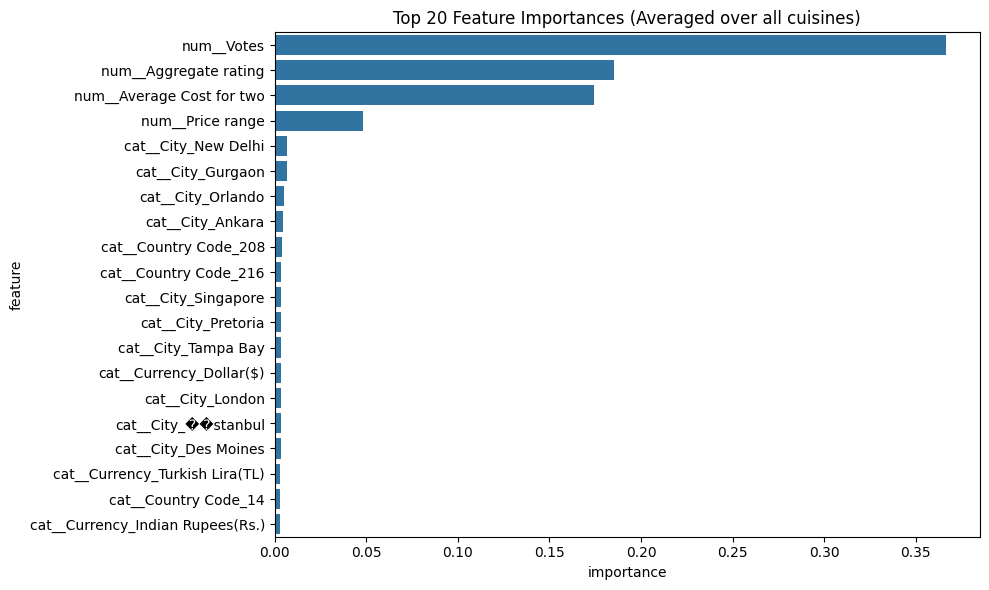

In [20]:
importances = np.mean([est.feature_importances_ for est in rf_model.estimators_], axis=0)
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importances (Averaged over all cuisines)')
plt.tight_layout()
plt.show()

In [21]:
model_artifacts = {
    'mlb': mlb,
    'preprocessor': preprocessor,
    'model': rf_model  # choose best model
}
joblib.dump(model_artifacts, 'cuisine_classifier.pkl')
print("Model saved.")

Model saved.


In [ ]:
loaded = joblib.load('cuisine_classifier.pkl')
mlb_loaded = loaded['mlb']
preprocessor_loaded = loaded['preprocessor']
model_loaded = loaded['model']

sample = pd.DataFrame([{
    'Country Code': 1,
    'City': 'New Delhi',
    'Average Cost for two': 800,
    'Currency': 'Indian Rupees(Rs.)',
    'Has Table booking': 'Yes',
    'Has Online delivery': 'No',
    'Is delivering now': 'No',
    'Price range': 3,
    'Votes': 150,
    'Aggregate rating': 4.2
}])

sample_processed = preprocessor_loaded.transform(sample)

# Get probabilities (list of arrays, one per label)
probabilities = model_loaded.predict_proba(sample_processed)

# Safely extract probability of positive class (class 1) for each label
probs = []
for prob in probabilities:
    if prob.shape[1] == 2:
        # Standard case: two columns [P(0), P(1)]
        probs.append(prob[0][1])
    else:
        # Edge case: only one column (assume it's P(1) if positive class exists, else P(0))
        # Since we're dealing with binary classification, we'll assume the single column is P(1)
        probs.append(prob[0][0])

probs = np.array(probs)
sorted_idx = np.argsort(probs)[::-1]

print("Top 5 most likely cuisines:")
for idx in sorted_idx[:5]:
    if probs[idx] > 0:
        print(f"  {mlb_loaded.classes_[idx]}: {probs[idx]:.3f}")

# Predict with default threshold (0.5)
pred_binary = model_loaded.predict(sample_processed)
predicted_cuisines = mlb_loaded.inverse_transform(pred_binary)
print("\nDefault prediction (threshold=0.5):", predicted_cuisines[0] if predicted_cuisines[0] else "None")

# Predict with lower threshold (e.g., 0.3)
threshold = 0.3
predicted_indices = [i for i, p in enumerate(probs) if p > threshold]
predicted_cuisines_custom = mlb_loaded.classes_[predicted_indices]
print(f"Prediction with threshold={threshold}:", list(predicted_cuisines_custom))

Top 5 most likely cuisines:
  Peruvian: 1.000
  Peranakan: 1.000
  B�_rek: 1.000
  Italian: 0.470
  Cafe: 0.420

Default prediction (threshold=0.5): None
Prediction with threshold=0.3: ['B�_rek', 'Cafe', 'Chinese', 'Continental', 'Italian', 'Peranakan', 'Peruvian']
